<a href="https://www.kaggle.com/code/abayomiadewale/lagos-airqo-9am?scriptVersionId=312668879" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Air Quality - PM2.5 Readings across Lagos at 9:00am today

## Import Libraries

In [1]:
# import necessary libraries
import requests
from pprint import pprint
from datetime import datetime, timedelta
from zoneinfo import ZoneInfo
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.io as pio
# import glob

# Access Lagos grid using Airqo API

In [2]:
# airqo api to access Lagos grid, requires security token

url_lagos = 'https://api.airqo.net/api/v2/devices/measurements/grids/64d635f18f492b0013406c46/recent'

### Specify start time and end time - 9:00am of current day

In [3]:
# Get the current date and time in Lagos
now_lagos = datetime.now(ZoneInfo("Africa/Lagos"))

# Create a datetime object for 9 AM today in Lagos
nine_am_today_lagos = now_lagos.replace(hour=9, minute=0, second=0, microsecond=0)

# Subtract 24 hours
nine_am_yesterday_lagos = nine_am_today_lagos - timedelta(hours=24)

# To obtain readings at current time
# today_minus_24hrs = now_lagos - timedelta(hours=24)

# Manually format the string
startTime = nine_am_yesterday_lagos.strftime('%Y-%m-%dT%H:%M:%S.%f')[:-3]
endTime = nine_am_today_lagos.strftime('%Y-%m-%dT%H:%M:%S.%f')[:-3]

print(startTime)
print(endTime)

2026-04-17T09:00:00.000
2026-04-18T09:00:00.000


In [4]:
# token
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("my_api_token")


In [5]:
# Check for json errors
# def fetch_data(url):
#     try:
#         response = requests.get(url)
#         response.raise_for_status()  # Check for HTTP errors
#         return response.json()  # Built-in JSON decoder
#     except requests.RequestException as e:
#         print(f"Network error: {e}")
#         return None
#     except json.JSONDecodeError as e:
#         print(f"JSON parsing error: {e}")
#         return None
    
# fetch_data(url_lagos)

## Request reading from 24-hours before to 9:00am

In [6]:
# request readings for a month from airqo api into json files
r = requests.get(url_lagos, params={'startTime': startTime, 'endTime': endTime, 'token': secret_value_0})
    
file_name = pd.to_datetime(endTime).strftime("%d-%B-%Y")
with open(f'/kaggle/working/{file_name}.json', "w") as json_file:
    json.dump(r.json()["measurements"], json_file, indent=4)

In [7]:
# r.json()

In [8]:
# write a function to merge daily readings into one json file
# def merge_json_files(directory_path):
#     merged_data = []
#     file_paths = glob.glob(directory_path + './*August-2024.json')
#     for path in file_paths:
#         with open(path, 'r') as file:
#             data = json.load(file)
#             merged_data.extend(data)
#     return merged_data

In [9]:
# execute merge function, output file and save into a variable
# directory_path = "C:/Users/abayomia/Documents/1_EEU/DATA MANAGEMENT/aqi_2024_files/"
# output_file = "rough_august_merged.json"
# merged_data = merge_json_files(directory_path)
# with open(output_file, 'w') as outfile:
#     json.dump(merged_data, outfile)

# pprint(merged_data)

## Read json file into dataframe

In [10]:
 # read data into pandas dataframe
read_data = pd.read_json(f'/kaggle/working/{file_name}.json')

In [11]:
read_data.head()

,device,device_id,site_id,time,pm2_5,pm10,frequency,no2,siteDetails,is_reading_primary,health_tips,device_categories,timeDifferenceHours,aqi_ranges,aqi_color,aqi_category,aqi_color_name,aqi_index
0,airqo_g5465,67d1467113e5ea001494f96d,6943a3fb09357b00130b607a,2026-04-18T09:00:00.000Z,{'value': 9.237400000000006},{'value': 2.814548818665188},hourly,{'value': None},"{'_id': '6943a3fb09357b00130b607a', 'visibilit...",True,"[{'_id': '64283ca1b2e9e5001e69c85f', 'title': ...","{'primary_category': 'lowcost', 'deployment_ca...",9.007668,"{'good': {'min': 0, 'max': 9.1}, 'moderate': {...",ECAA06,Moderate,Yellow,51
1,airqo_g5503,6825ad38c23a5b00136bfefc,6943a3984973ef0013d271a6,2026-04-18T09:00:00.000Z,{'value': 7.889200000000046},{'value': -0.48354008885661204},hourly,{'value': None},"{'_id': '6943a3984973ef0013d271a6', 'visibilit...",True,"[{'_id': '64283ca1b2e9e5001e69c85f', 'title': ...","{'primary_category': 'lowcost', 'deployment_ca...",9.007668,"{'good': {'min': 0, 'max': 9.1}, 'moderate': {...",34C759,Good,Green,43
2,airqo-g5180,646c8c60f41bc600299f4eb3,661bb5b57103020013ab8caf,2026-04-18T07:00:00.000Z,{'value': 8.014299999999995},{'value': 8.327599496866066},hourly,{'value': None},"{'_id': '661bb5b57103020013ab8caf', 'visibilit...",True,"[{'_id': '64283ca1b2e9e5001e69c85f', 'title': ...","{'primary_category': 'lowcost', 'deployment_ca...",11.007668,"{'good': {'min': 0, 'max': 9.1}, 'moderate': {...",34C759,Good,Green,44
3,airqo_g5237,649355c7df2ae7001e5f86b5,64d3a92c47fc640013c6c284,2026-04-18T05:00:00.000Z,{'value': 15.142900000000054},{'value': 21.03088014513208},hourly,{'value': None},"{'_id': '64d3a92c47fc640013c6c284', 'formatted...",True,"[{'_id': '64283ce9e82a77001e55c0b5', 'title': ...","{'primary_category': 'lowcost', 'deployment_ca...",13.007668,"{'good': {'min': 0, 'max': 9.1}, 'moderate': {...",ECAA06,Moderate,Yellow,62
4,airqo_g5213,6493462da704ef001e6d3463,64d3abf8f5fc5e00133e799b,2026-04-18T09:00:00.000Z,{'value': 9.509400000000026},{'value': 2.120218616204012},hourly,{'value': None},"{'_id': '64d3abf8f5fc5e00133e799b', 'formatted...",True,"[{'_id': '64283ca1b2e9e5001e69c85f', 'title': ...","{'primary_category': 'lowcost', 'deployment_ca...",9.007668,"{'good': {'min': 0, 'max': 9.1}, 'moderate': {...",ECAA06,Moderate,Yellow,52


In [12]:
# get parameters for reference

# pprint(read_data['siteDetails'][0].keys())
# pprint('')
# pprint(read_data['siteDetails'][0].values())
# pprint('')
pprint(read_data['siteDetails'][0])
print('\n')
print(read_data['pm2_5'][0].values())
print(read_data['pm10'][0].values())

{'_id': '6943a3fb09357b00130b607a',
 'approximate_latitude': 6.591529863675653,
 'approximate_longitude': 3.384542859571183,
 'bearing_in_radians': 3.156,
 'city': 'Ikeja',
 'country': 'Nigeria',
 'county': 'Kosofe',
 'data_provider': 'AirQo',
 'description': 'Ikosi Market',
 'district': 'Kosofe',
 'formatted_name': 'Tipper Garage, Ikorodu Road Access, Ketu, Ikeja 105102, '
                   'Lagos, Nigeria',
 'lastRawData': '2026-04-18T16:56:54.000Z',
 'latest_pm2_5': {'calibrated': {'standardDeviation': None,
                                 'time': '2026-04-18T15:00:00.000Z',
                                 'uncertainty': None,
                                 'value': 17.32010000000007},
                  'raw': {'time': '2026-04-18T16:56:54.000Z', 'value': 23.58}},
 'location_name': 'Lagos, Nigeria',
 'name': 'Ikosi Market',
 'rawOnlineStatus': True,
 'region': 'Lagos',
 'search_name': 'Ikorodu Road Access',
 'site_category': {'category': 'Unknown_Category'},
 'street': 'Ikorodu

In [13]:
# get all location identifiers for resolution of conflicting names
for detail in read_data['siteDetails']:
    pprint(f"name: {detail['name']}")
    pprint(f"search_name: {detail['search_name']}")
    pprint(f"location_name: {detail['location_name']}")
    # pprint(f"street: {detail['street']}")
    pprint(f"formatted_name: {detail['formatted_name']}")
    print('\n')

'name: Ikosi Market'
'search_name: Ikorodu Road Access'
'location_name: Lagos, Nigeria'
('formatted_name: Tipper Garage, Ikorodu Road Access, Ketu, Ikeja 105102, '
 'Lagos, Nigeria')


'name: Majidun BRT Depot Ikorodu'
'search_name: Ikorodu Road 658'
'location_name: Lagos, Nigeria'
('formatted_name: Majidun, JF97+R44, Ikorodu Rd, Majidun Ilaje 104101, Lagos, '
 'Nigeria')


'name: Saluwala, Lagos,  Nigeria'
'search_name: Eti-Osa 412'
'location_name: Lagos, Nigeria'
'formatted_name: 14 Kasika Street, Eti-Osa, Saluwala 106104, Lagos, Nigeria'


'name: LASEPA Ikeja Lagos, Nigeria'
'search_name: LASEPA, Ikeja'
'location_name: Lagos, Nigeria'
"formatted_name: J976+58F, Governor's Ave, Oregun 101233, Ikeja, Lagos, Nigeria"


'name: Agege, Lagos, Nigeria'
'search_name: Agege'
'location_name: Lagos, Nigeria'
('formatted_name: 15 Seyinsola Coker Street, Ifako-Ijaiye 100283, Agege, '
 'Lagos, Nigeria')


'name: Epe, Lagos, Nigeria'
'search_name: Lasu Road'
'location_name: Lagos, Nigeria'
'format

In [14]:
# some locations don't have street names
for detail in read_data['siteDetails']:
    try:
        pprint(f"street: {detail['street']}")
    except:
        print('no street name')

# drop use of street names

'street: Ikorodu Road Access'
'street: Ikorodu Road'
'street: Kasika Street'
"street: Governor's Avenue"
'street: Seyinsola Coker Street'
'street: Lasu Road'
'street: F100'


In [15]:
# check location names
# for detail in read_data['siteDetails']:
    # pprint(f"street: {detail['street']}")
    # pprint(f"name: {detail['name']}")
    # pprint(f"search_name: {detail['search_name']}")
    # pprint(f"location_name: {detail['location_name']}")
    # print('\n')

In [16]:
read_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   device               7 non-null      object 
 1   device_id            7 non-null      object 
 2   site_id              7 non-null      object 
 3   time                 7 non-null      object 
 4   pm2_5                7 non-null      object 
 5   pm10                 7 non-null      object 
 6   frequency            7 non-null      object 
 7   no2                  7 non-null      object 
 8   siteDetails          7 non-null      object 
 9   is_reading_primary   7 non-null      bool   
 10  health_tips          7 non-null      object 
 11  device_categories    7 non-null      object 
 12  timeDifferenceHours  7 non-null      float64
 13  aqi_ranges           7 non-null      object 
 14  aqi_color            7 non-null      object 
 15  aqi_category         7 non-null      object 

### Normalize/unpack dictionaries

In [17]:
# normalize/unpack dictionaries to obtain location name and calibrated PM2.5 readings
site_details_expand = pd.json_normalize(read_data['siteDetails'])
# pm2_5_expand = pd.json_normalize(read_data['pm2_5'])
# pm10_expand = pd.json_normalize(read_data['pm10'])

In [18]:
# Fix issue with duplicated 'Eti-Osa' locations
site_details_expand.loc[site_details_expand["search_name"] == "Eti-Osa", "search_name"] = site_details_expand['street'].str.cat(site_details_expand['search_name'], sep=", ")

In [19]:
 # join unpacked 'siteDetails' column
expand_data = read_data.join(site_details_expand)

In [20]:
# column options for API version
# list_1 = ['device', 'device_id', 'is_reading_primary', 'health_tips', 'site_id',
#                   'frequency', 'no2', 'timeDifferenceHours', 'siteDetails', 'val1', 'val2',
#                   'aqi_color', 'aqi_category', 'aqi_color_name', '_id', 'visibility',
#                   'street', 'parish', 'village', 'formatted_name', 'location_name', 'name',
#                   'sub_county', 'town', 'city', 'district', 'county', 'region', 'country',
#                   'approximate_latitude', 'approximate_longitude',
#                   'bearing_in_radians', 'data_provider', 'description']


# list_2 = ['device', 'device_id', 'site_id', 'time', 'frequency',
#        'no2', 'siteDetails', '_id', 'formatted_name', 'street', 'town', 'city',
#        'district', 'county', 'region', 'country', 'name',
#        'approximate_latitude', 'approximate_longitude', 'bearing_in_radians',
#        'description', 'location_name', 'search_name', 'data_provider',
#        'visibility', 'parish', 'village', 'sub_county']


# set(list_1).intersection(set(list_2))
# set(list_1).difference(set(list_2))

In [21]:
# rename 'pm2_5' and 'pm10' to ease dropping
expand_data.rename(columns={'pm2_5':'val1', 'pm10':'val2'}, inplace=True)

In [22]:
expand_data.columns

Index(['device', 'device_id', 'site_id', 'time', 'val1', 'val2', 'frequency',
       'no2', 'siteDetails', 'is_reading_primary', 'health_tips',
       'device_categories', 'timeDifferenceHours', 'aqi_ranges', 'aqi_color',
       'aqi_category', 'aqi_color_name', 'aqi_index', '_id', 'visibility',
       'rawOnlineStatus', 'lastRawData', 'formatted_name', 'location_name',
       'search_name', 'street', 'town', 'city', 'district', 'county', 'region',
       'country', 'name', 'approximate_latitude', 'approximate_longitude',
       'bearing_in_radians', 'data_provider', 'description',
       'site_category.category', 'latest_pm2_5.raw.value',
       'latest_pm2_5.raw.time', 'latest_pm2_5.calibrated.value',
       'latest_pm2_5.calibrated.time', 'latest_pm2_5.calibrated.uncertainty',
       'latest_pm2_5.calibrated.standardDeviation', 'parish', 'village',
       'sub_county'],
      dtype='object')

In [23]:
# check for change in parameters
current_drop_dict = {'device', 'device_id', 'is_reading_primary', 'health_tips', 'site_id',
       'val1', 'val2', 'frequency', 'no2', 'siteDetails',
       'timeDifferenceHours',
       '_id', 'visibility', 'town', 'city', 'formatted_name',
       'location_name', 'district', 'county', 'region',
       'country', 'name', 'street', 'groups', 'parish', 'village', 'sub_county',
       'bearing_in_radians', 'data_provider', 'description', 'lastActive',
       'isOnline', 'site_category.tags', 'site_category.area_name',
       'site_category.category', 'site_category.highway',
       'site_category.landuse', 'site_category.latitude',
       'site_category.longitude', 'site_category.natural',
       'site_category.search_radius', 'site_category.waterway'}

updated_drop_dict = {'device', 'device_id', 'site_id', 'time', 'val1', 'val2', 'frequency',
       'no2', 'siteDetails', 'is_reading_primary', 'health_tips',
       'timeDifferenceHours', 'aqi_ranges', 'aqi_color', 'aqi_category',
       'aqi_color_name', '_id', 'visibility', 'formatted_name',
       'location_name', 'search_name', 'town', 'city', 'district', 'county',
       'region', 'country', 'name', 'approximate_latitude',
       'approximate_longitude', 'bearing_in_radians', 'data_provider',
       'description', 'lastRawData', 'rawOnlineStatus',
       'site_category.category', 'latest_pm2_5.raw.value',
       'latest_pm2_5.raw.time', 'latest_pm2_5.calibrated.value',
       'latest_pm2_5.calibrated.time', 'latest_pm2_5.calibrated.uncertainty',
       'latest_pm2_5.calibrated.standardDeviation', 'street'}

modified_drop_dict = {'device', 'device_id', 'is_reading_primary', 'health_tips', 'site_id',
       'val1', 'val2', 'frequency', 'no2', 'siteDetails', 'latest_pm2_5.calibrated.time',
       'timeDifferenceHours', 'lastRawData', 'latest_pm2_5.calibrated.standardDeviation',
       '_id', 'visibility', 'town', 'city', 'formatted_name', 'latest_pm2_5.calibrated.standardDeviation'
       'location_name', 'district', 'county', 'region', 'latest_pm2_5.raw.time', 'latest_pm2_5.raw.value',
       'country', 'name', 'street', 'latest_pm2_5.calibrated.uncertainty', 'rawOnlineStatus',
       'bearing_in_radians', 'data_provider', 'description', 'site_category.category', 'location_name'}

updated_drop_dict.difference(modified_drop_dict)

{'approximate_latitude',
 'approximate_longitude',
 'aqi_category',
 'aqi_color',
 'aqi_color_name',
 'aqi_ranges',
 'latest_pm2_5.calibrated.value',
 'search_name',
 'time'}

In [24]:
expand_data.head(3)

,device,device_id,site_id,time,val1,val2,frequency,no2,siteDetails,is_reading_primary,...,site_category.category,latest_pm2_5.raw.value,latest_pm2_5.raw.time,latest_pm2_5.calibrated.value,latest_pm2_5.calibrated.time,latest_pm2_5.calibrated.uncertainty,latest_pm2_5.calibrated.standardDeviation,parish,village,sub_county
0,airqo_g5465,67d1467113e5ea001494f96d,6943a3fb09357b00130b607a,2026-04-18T09:00:00.000Z,{'value': 9.237400000000006},{'value': 2.814548818665188},hourly,{'value': None},"{'_id': '6943a3fb09357b00130b607a', 'visibilit...",True,...,Unknown_Category,23.58,2026-04-18T16:56:54.000Z,17.3201,2026-04-18T15:00:00.000Z,None,None,NaN,NaN,NaN
1,airqo_g5503,6825ad38c23a5b00136bfefc,6943a3984973ef0013d271a6,2026-04-18T09:00:00.000Z,{'value': 7.889200000000046},{'value': -0.48354008885661204},hourly,{'value': None},"{'_id': '6943a3984973ef0013d271a6', 'visibilit...",True,...,Unknown_Category,9.05,2026-04-18T17:26:07.000Z,8.8295,2026-04-18T15:00:00.000Z,None,None,NaN,NaN,NaN
2,airqo-g5180,646c8c60f41bc600299f4eb3,661bb5b57103020013ab8caf,2026-04-18T07:00:00.000Z,{'value': 8.014299999999995},{'value': 8.327599496866066},hourly,{'value': None},"{'_id': '661bb5b57103020013ab8caf', 'visibilit...",True,...,Urban Background,7.30,2026-04-18T07:47:57.000Z,8.0143,2026-04-18T07:00:00.000Z,None,None,Eti-Osa,Eti-Osa,Eti-Osa


In [25]:
# expand_data['siteDetails'][0]

In [26]:
# data['site_category.category'].unique()

### Drop unnecessary columns

In [27]:
# drop necessary columns

# data = data.drop(['device', 'device_id', 'is_reading_primary', 'health_tips', 'site_id',
#        'val1', 'val2', 'frequency', 'no2', 'siteDetails',
#        'timeDifferenceHours',
#        '_id', 'visibility', 'town', 'city', 'formatted_name',
#        'location_name', 'district', 'county', 'region',
#        'country', 'name', 'street',
#        'bearing_in_radians', 'data_provider', 'description'], axis=1)

In [28]:
data = expand_data[['approximate_latitude',
 'approximate_longitude',
 'aqi_category',
 'aqi_color',
 'aqi_color_name',
 'latest_pm2_5.calibrated.value',
 'search_name',
 'time']]

In [29]:
# copy cleaned DataFrame
clean_data = data.copy()

In [30]:
# unpack and join pm data
# data = data.join(pm2_5_expand).rename(columns={'value':'pm2_5'})
# data = data.join(pm10_expand).rename(columns={'value':'pm10'})

In [31]:
# rename search_name as location
clean_data.rename(columns={'search_name':'location', 'latest_pm2_5.calibrated.value':'pm2_5'}, inplace=True)

In [32]:
# convert time to datetime
clean_data['time'] = pd.to_datetime(clean_data['time'])

In [33]:
# check locations for uniqueness
pprint(clean_data['location'].unique())
print('\n')
print(clean_data['location'].nunique())

array(['Ikorodu Road Access', 'Ikorodu Road 658', 'Eti-Osa 412',
       'LASEPA, Ikeja', 'Agege', 'Lasu Road', 'F100'], dtype=object)


7


In [34]:
clean_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   approximate_latitude   7 non-null      float64            
 1   approximate_longitude  7 non-null      float64            
 2   aqi_category           7 non-null      object             
 3   aqi_color              7 non-null      object             
 4   aqi_color_name         7 non-null      object             
 5   pm2_5                  7 non-null      float64            
 6   location               7 non-null      object             
 7   time                   7 non-null      datetime64[ns, UTC]
dtypes: datetime64[ns, UTC](1), float64(3), object(4)
memory usage: 576.0+ bytes


In [35]:
# replace location values for easy referencing
# data['location'].replace({'F100': 'Badagry', 'Eti-Osa 412': 'Eti-Osa', 'Agege 512': 'Ifako-Ijaiye'}, inplace=True)
clean_data.replace({'location': {'F100': 'Badagry', 'Eti-Osa 412': 'Eti-Osa', 'Agege 512': 'Ifako-Ijaiye'}}, inplace=True)

In [36]:
clean_data.head(2)

,approximate_latitude,approximate_longitude,aqi_category,aqi_color,aqi_color_name,pm2_5,location,time
0,6.591530,3.384543,Moderate,ECAA06,Yellow,17.3201,Ikorodu Road Access,2026-04-18 09:00:00+00:00
1,6.620278,3.467256,Good,34C759,Green,8.8295,Ikorodu Road 658,2026-04-18 09:00:00+00:00


In [37]:
pprint(clean_data['location'])

0    Ikorodu Road Access
1       Ikorodu Road 658
2                Eti-Osa
3          LASEPA, Ikeja
4                  Agege
5              Lasu Road
6                Badagry
Name: location, dtype: object


## Group data by 24-hour average

In [38]:
# groupby search_name and resample to day
# grouper = data.groupby(['location', 'approximate_latitude', 'approximate_longitude']).resample('1h', on='time')
# grouper = data.groupby(['location', 'approximate_latitude', 'approximate_longitude']).resample(how=[np.mean, pd.Series.count, len])

grouper = clean_data.groupby(['location', 'approximate_latitude', 'approximate_longitude'])
    
# use grouper to aggregate on average value
data_output = pd.DataFrame(grouper['pm2_5'].mean()).reset_index()

# round `pm2_5` values to 1 decimal place
data_output['pm2_5'] = round(data_output['pm2_5'], 1)

In [39]:
data_output

,location,approximate_latitude,approximate_longitude,pm2_5
0,Agege,6.649323,3.322736,9.3
1,Badagry,6.435793,2.912502,9.5
2,Eti-Osa,6.479774,3.609130,8.0
3,Ikorodu Road 658,6.620278,3.467256,8.8
4,Ikorodu Road Access,6.591530,3.384543,17.3
5,"LASEPA, Ikeja",6.615861,3.357184,9.5
6,Lasu Road,6.583519,4.001062,12.8


### Establish colour codes with list comprehension

In [40]:
# create color coding for bar chart via list comprehension
cols = ['green' if x <= 12 else 'yellow' if 12.1 <= x <= 35.4 else 'orange' if 35.5 <= x <= 55.4 else 'red' if 55.5 <= x <= 150.4 else 'purple' if 150.5 <= x <= 250.4 else 'maroon' for x in data_output['pm2_5']]

In [41]:
# create legend labels and legend maps for categories

legend_labels = ['Good', 'Moderate', 'Unhealthy for Sensitive groups', 'Unhealthy', 'Very Unhealthy', 'Hazardous']
legend_color_map = {'Good':'green',
                    'Moderate':'yellow',
                    'Unhealthy for Sensitive groups':'orange',
                    'Unhealthy':'red',
                    'Very Unhealthy':'purple',
                    'Hazardous':'maroon'}

# create custom legend handles using `matplotlib patches`
handles = [mpatches.Patch(color=legend_color_map[label], label=label) for label in legend_labels]

In [42]:
# A check to properly format file identifier
pd.to_datetime(endTime).strftime("%A-%d-%B-%Y.%I_%M_%S")

'Saturday-18-April-2026.09_00_00'

# Plots

## Seaborn barplot and png export

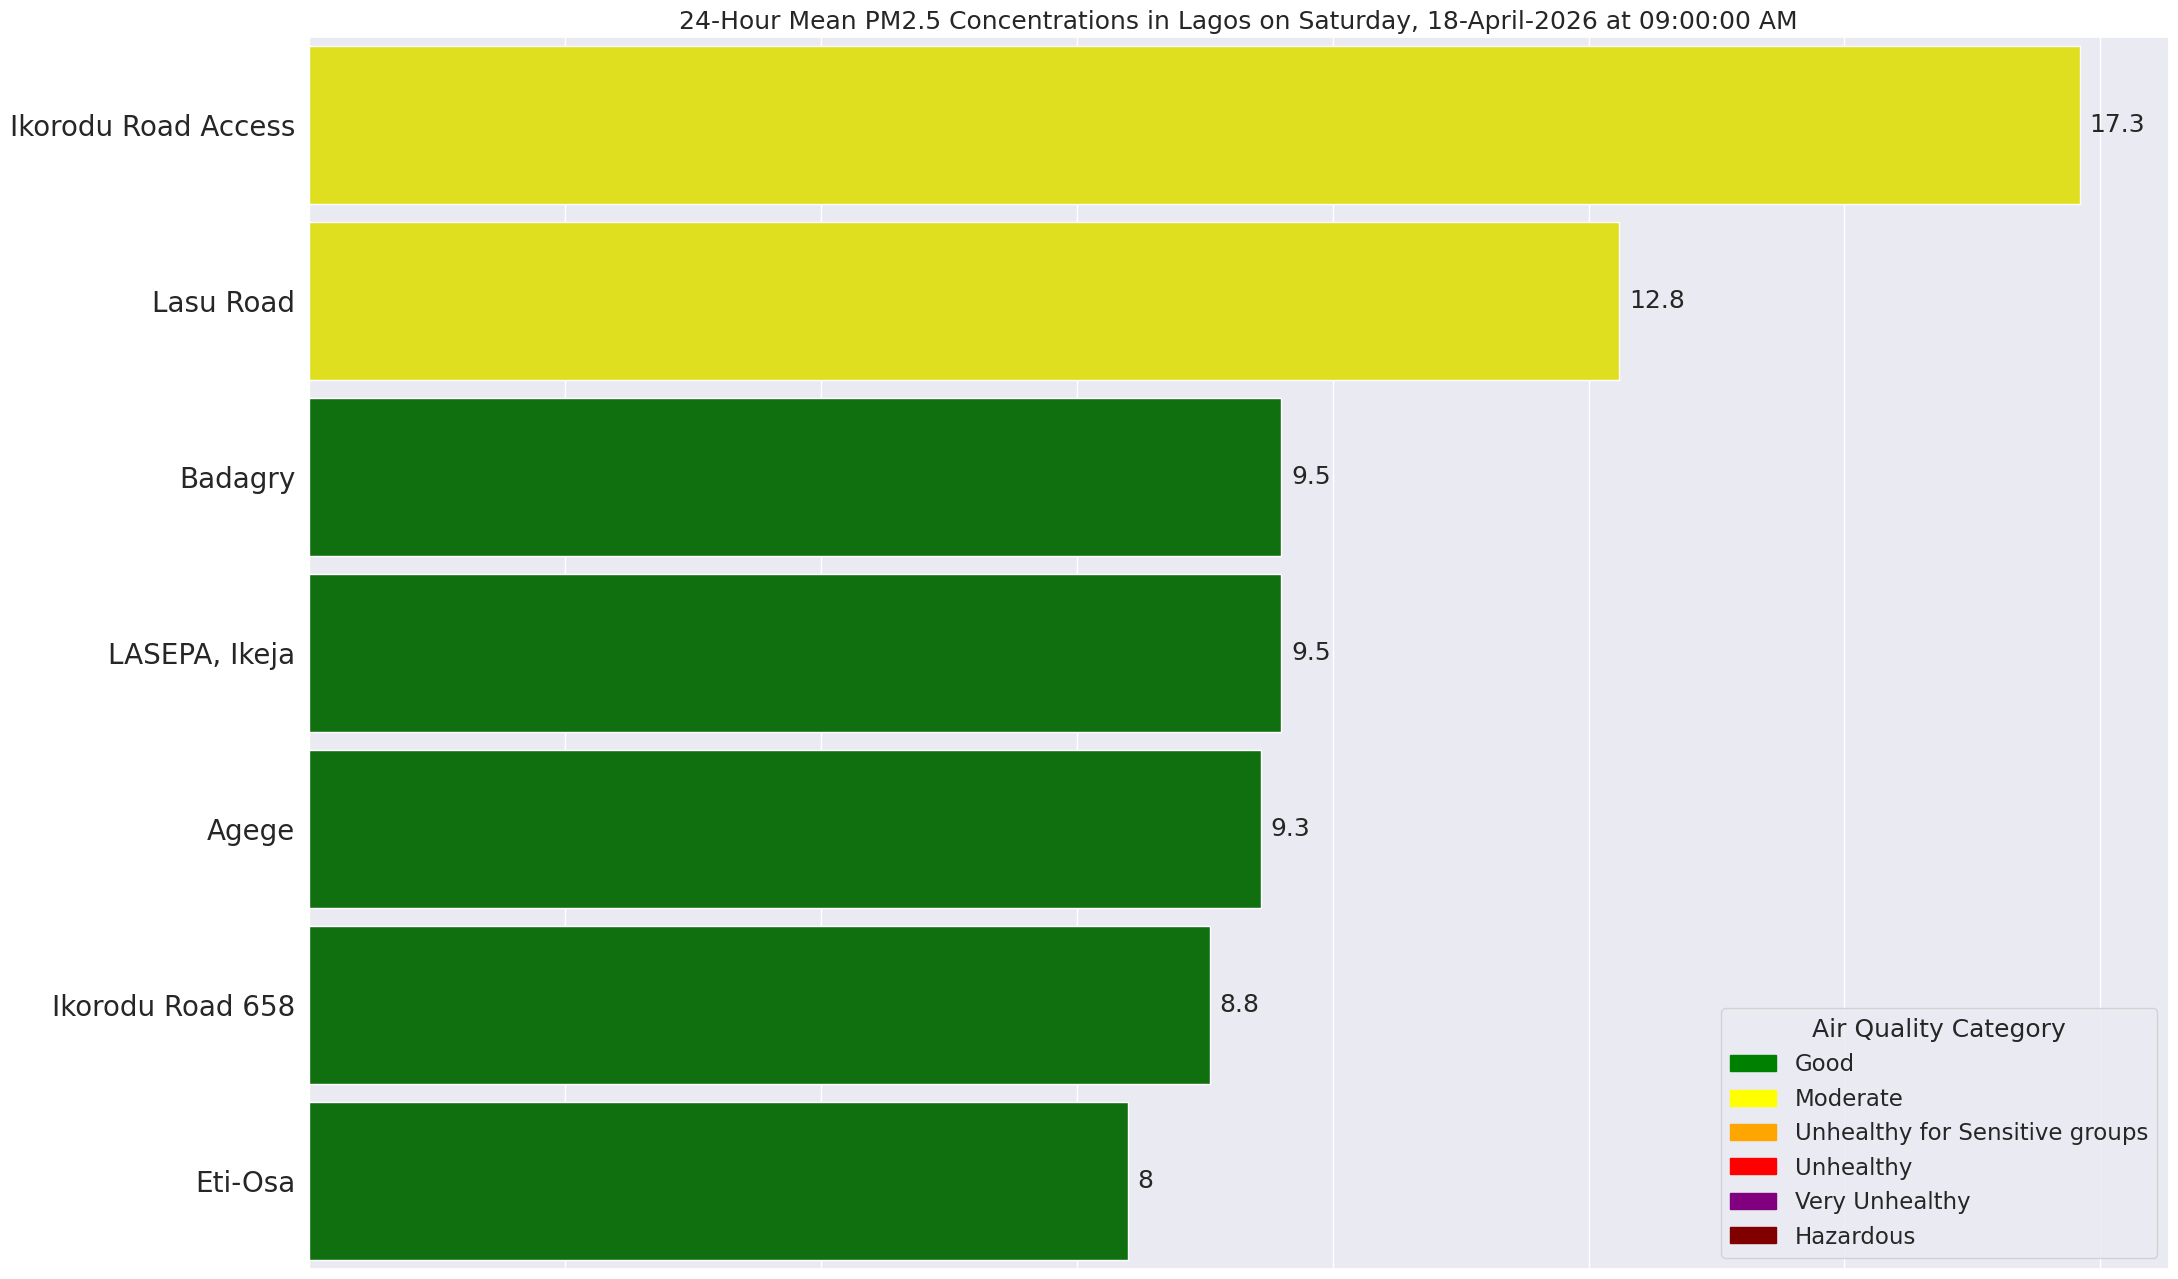

In [43]:
# plot the chart

# set file_name time suffix
file_suffix = pd.to_datetime(endTime).strftime("%A-%d-%B-%Y-%I-%M-%S")

# set font scale
sns.set_theme(font_scale=1.5)

# set figsize
fig, ax = plt.subplots(figsize=(24, 16))

# Explicitly map colors to locations
color_mapping = dict(zip(data_output['location'], cols))

# bar plot using seaborn
ax = sns.barplot(data_output,
                 y='location',
                 x='pm2_5',
                 order=data_output.sort_values('pm2_5', ascending=False).location,
                 errorbar=None,
                 palette=color_mapping,
                 # hue=cols,  # won't work; colors not mapped
                 width=0.9
                )

# set no labels for sake of graphic design editors
ax.set(xlabel=None, ylabel=None, xticklabels=[])

# set label size for ticks
plt.tick_params(labelsize=20)

# set title
plt.title(f'24-Hour Mean PM2.5 Concentrations in Lagos on {nine_am_today_lagos.strftime("%A, %d-%B-%Y")} at {nine_am_today_lagos.strftime("%r")}',)

# add legend
plt.legend(handles=handles, title='Air Quality Category')
# ax.get_legend().remove()

# set values to be shown as labels for each bar
for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=7)

# save barplot
plt.savefig(f"/kaggle/working/lagos_{file_suffix}", bbox_inches='tight', pad_inches=0.5)

plt.show()

### Deploy dynamic chart using Plotly

In [44]:
# function to categorize according to color
def category_color(x):
    if x < 12:
        return 'green'
    elif 12 < x < 35.5:
        return 'yellow'
    elif 35.4 < x < 55.5:
        return 'orange'
    elif 55.4 < x < 150.5:
        return 'red'
    elif 150.4 < x < 250.5:
        return 'purple'
    else:
        return 'maroon'

In [45]:
# function to categorize according to severity
def category_cat(x):
    if x < 12:
        return 'good'
    elif 12 < x < 35.5:
        return 'moderate'
    elif 35.4 < x < 55.5:
        return 'unhealthy for sensitive groups'
    elif 55.4 < x < 150.5:
        return 'unhealthy'
    elif 155.4 < x < 250.5:
        return 'very unhealthy'
    else:
        return 'hazardous'

In [46]:
# create 'color' column
data_output['color'] = data_output['pm2_5'].apply(category_color)

In [47]:
# create 'aqi_category' column
data_output['aqi_category'] = data_output['pm2_5'].apply(category_cat)

In [48]:
data_output

,location,approximate_latitude,approximate_longitude,pm2_5,color,aqi_category
0,Agege,6.649323,3.322736,9.3,green,good
1,Badagry,6.435793,2.912502,9.5,green,good
2,Eti-Osa,6.479774,3.609130,8.0,green,good
3,Ikorodu Road 658,6.620278,3.467256,8.8,green,good
4,Ikorodu Road Access,6.591530,3.384543,17.3,yellow,moderate
5,"LASEPA, Ikeja",6.615861,3.357184,9.5,green,good
6,Lasu Road,6.583519,4.001062,12.8,yellow,moderate


In [49]:
# assign color values to aqi categories for plotly scatter_map attribute
color_discrete_mapper = {'good': 'green', 'moderate': 'yellow', 'unhealthy for sensitive groups': 'orange', 'unhealthy': 'red', 'very unhealthy': 'purple', 'hazardous': 'maroon'}

## Plotly interactive bar chart

In [50]:
# plotly bar chart
fig = px.bar(data_output, y='location', x='pm2_5',
                 title=f'24-Hour Mean PM2.5 Concentrations in Lagos on {nine_am_today_lagos.strftime("%A, %d-%B-%Y")} at {nine_am_today_lagos.strftime("%r")}',
                 hover_name="location",
                 hover_data= ["pm2_5", "aqi_category"],
                 color='aqi_category',
                 color_discrete_sequence=cols,
                 color_discrete_map=color_discrete_mapper,
                 text_auto=True,
                 labels={'pm2_5':'PM 2.5', 'aqi_category':'Severity'})

fig.update_traces(textposition='outside')
fig.update_layout(yaxis = {"categoryorder":"total ascending"})

# remove axis labels
fig.update_yaxes(title='')
fig.update_xaxes(title='')

fig.show()

## Plotly interactive map

In [51]:
# create interactive map using plotly express
fig = px.scatter_map(data_output, lat='approximate_latitude', lon='approximate_longitude', color='aqi_category', 
                     hover_name='location', size='pm2_5', size_max=15, color_discrete_map=color_discrete_mapper,
                     title=f'24-Hour Mean PM2.5 Concentrations in Lagos on {nine_am_today_lagos.strftime("%A, %d-%B-%Y")} at {nine_am_today_lagos.strftime("%r")}',
                     labels={'pm2_5':'PM 2.5', 'location':'Location', 'aqi_category':'Severity'})

fig.update_layout(geo_scope = 'africa')

fig.show()

In [52]:
# save interactive html to local drive directory
# with open(f'map_{file_name}.html', 'a') as foo:
#     foo.write(pio.to_html(fig, full_html=True))

# with open('interactive_plot.html', 'a', encoding="utf-8") as filen:
    # filen.write(pio.to_html(fig, full_html=True));

In [53]:
# pio.write_html(fig, file='index.html', auto_open=True)

In [54]:
# save to csv
# data_output.to_csv(f'lagos_{file_name}_to_looker.csv', index = False)